# **2. Data Acquisition and Unification**

To build a truly comprehensive model, we must train it on diverse and extensive data. We will use the following Kaggle datasets. **Please ensure you add all of them to your Kaggle Notebook via the "+ Add data" button.**

1.  **NIH ChestX-ray14:** The largest publicly available dataset, with over 100,000 images and 14 common pathology labels.
    *   Kaggle Path: `/kaggle/input/nih-chest-xrays/`
2.  **CheXpert:** A massive dataset from Stanford University, with over 200,000 images, labeled for the same 14 pathologies, with a focus on handling uncertainty.
    *   Kaggle Path: `/kaggle/input/chexpert/`
3.  **Chest X-Ray Images (Pneumonia):** A smaller, focused dataset perfect for demonstrating subtype classification (Bacterial vs. Viral).
    *   Kaggle Path: `/kaggle/input/chest-xray-pneumonia/`

Our first step is to create a unified labeling system, our **`MASTER_FINDINGS`**, that all datasets will be mapped to.

In [2]:
# Define the master list of pathologies we want to detect.
# This list is a superset of the common findings in NIH and CheXpert datasets.
MASTER_FINDINGS = [
    'Atelectasis',
    'Cardiomegaly',
    'Consolidation',
    'Edema',
    'Effusion',
    'Emphysema',
    'Fibrosis',
    'Hernia',
    'Infiltration',
    'Mass',
    'Nodule',
    'Pleural_Thickening',
    'Pneumonia',
    'Pneumothorax',
    'No Finding' # Represents a normal scan
]

# Define paths to datasets (ensure these match your Kaggle input directories)
NIH_DATA_PATH = '/kaggle/input/data'
CHEXPERT_DATA_PATH = '/kaggle/input/chexpert'
PNEUMONIA_DATA_PATH = '/kaggle/input/chest-xray-pneumonia/chest_xray/'

print(f"Master label schema created with {len(MASTER_FINDINGS)} findings.")

Master label schema created with 15 findings.


In [3]:
# --- Step 1: Process the NIH Dataset ---
print("Processing NIH ChestX-ray14 dataset...")
nih_df = pd.read_csv(os.path.join(NIH_DATA_PATH, 'Data_Entry_2017.csv'))
nih_df.rename(columns={'Image Index': 'Image_Index', 'Finding Labels': 'Finding_Labels'}, inplace=True)

# Create full image paths
nih_df['filepath'] = nih_df['Image_Index'].apply(
    lambda x: os.path.join(NIH_DATA_PATH, 'images', x)
)

# One-hot encode the labels based on our MASTER_FINDINGS schema
for finding in MASTER_FINDINGS:
    # We map 'Infiltration' from NIH to our 'Pneumonia' label as they are often used interchangeably in this context.
    # This is a common practice for this dataset.
    if finding == 'Pneumonia':
         nih_df[finding] = nih_df['Finding_Labels'].apply(lambda x: 1 if 'Infiltration' in x or 'Pneumonia' in x else 0)
    else:
        nih_df[finding] = nih_df['Finding_Labels'].apply(lambda x: 1 if finding in x else 0)


print(f"NIH dataset processed. Shape: {nih_df.shape}")
nih_df[['filepath'] + MASTER_FINDINGS].head()

Processing NIH ChestX-ray14 dataset...
NIH dataset processed. Shape: (112120, 28)


,filepath,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,No Finding
0,/kaggle/input/data/images/00000001_000.png,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,/kaggle/input/data/images/00000001_001.png,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,/kaggle/input/data/images/00000001_002.png,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,/kaggle/input/data/images/00000002_000.png,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,/kaggle/input/data/images/00000003_000.png,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [4]:
# --- Step 2: Process the CheXpert Dataset ---
print("\nProcessing CheXpert dataset...")
# We use the validation set for this demo due to its smaller size and cleaner labels.
# For a full production model, you should process the entire training set.
chexpert_df = pd.read_csv(os.path.join(CHEXPERT_DATA_PATH, 'valid.csv'))
chexpert_df['filepath'] = chexpert_df['Path'].apply(lambda x: os.path.join(CHEXPERT_DATA_PATH, '/'.join(x.split('/')[1:])))

# Map CheXpert columns to our MASTER_FINDINGS schema
# CheXpert uses 'Pleural Effusion' while NIH uses 'Effusion'. We unify them.
chexpert_df.rename(columns={'Pleural Effusion': 'Effusion'}, inplace=True)

# Handle uncertain labels (-1). A common strategy is to treat them as positives (1) to maximize sensitivity.
chexpert_df = chexpert_df.fillna(0) # Replace NaN with 0 (negative)
chexpert_df = chexpert_df.replace(-1, 1) # Replace -1 (uncertain) with 1 (positive)

# Select and create one-hot encoded columns for the master list
for finding in MASTER_FINDINGS:
    if finding not in chexpert_df.columns:
        chexpert_df[finding] = 0 # Add columns that don't exist in CheXpert

print(f"CheXpert dataset processed. Shape: {chexpert_df.shape}")
chexpert_df[['filepath'] + MASTER_FINDINGS].head()


Processing CheXpert dataset...
CheXpert dataset processed. Shape: (234, 27)


,filepath,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,No Finding
0,/kaggle/input/chexpert/valid/patient64541/stud...,0.0,1.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0
1,/kaggle/input/chexpert/valid/patient64542/stud...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0
2,/kaggle/input/chexpert/valid/patient64542/stud...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0
3,/kaggle/input/chexpert/valid/patient64543/stud...,0.0,0.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0
4,/kaggle/input/chexpert/valid/patient64544/stud...,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,1.0


In [5]:
# --- Step 3: Process the Pneumonia Dataset and SIMULATE advanced labels ---
print("\nProcessing Pneumonia dataset and simulating advanced labels...")
pneumonia_filepaths = []
pneumonia_labels_onehot = []
pneumonia_subtypes = []
pneumonia_severities_simulated = []

for split in ['train', 'test', 'val']:
    base_path = os.path.join(PNEUMONIA_DATA_PATH, split)
    for folder in ['NORMAL', 'PNEUMONIA']:
        folder_path = os.path.join(base_path, folder)
        for filename in os.listdir(folder_path):
            filepath = os.path.join(folder_path, filename)
            pneumonia_filepaths.append(filepath)
            
            # Create one-hot labels
            labels = {f: 0 for f in MASTER_FINDINGS}
            subtype = 'N/A'
            severity = 'N/A'
            
            if folder == 'NORMAL':
                labels['No Finding'] = 1
            else: # PNEUMONIA
                labels['Pneumonia'] = 1
                # Subtype classification based on filename
                if 'bacteria' in filename:
                    subtype = 'Bacterial'
                    # SIMULATE severity: bacterial is often more severe
                    severity = random.choice(['Moderate', 'Severe'])
                elif 'virus' in filename:
                    subtype = 'Viral'
                    # SIMULATE severity: viral is often milder
                    severity = random.choice(['Mild', 'Moderate'])

            pneumonia_labels_onehot.append(labels)
            pneumonia_subtypes.append(subtype)
            pneumonia_severities_simulated.append(severity)

pneumonia_df = pd.DataFrame(pneumonia_labels_onehot)
pneumonia_df['filepath'] = pneumonia_filepaths
pneumonia_df['Subtype'] = pneumonia_subtypes
pneumonia_df['Severity_Simulated'] = pneumonia_severities_simulated

print(f"Pneumonia dataset processed. Shape: {pneumonia_df.shape}")
pneumonia_df.sample(5)


Processing Pneumonia dataset and simulating advanced labels...
Pneumonia dataset processed. Shape: (5856, 18)


,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,No Finding,filepath,Subtype,Severity_Simulated
3894,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,Bacterial,Severe
2186,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,Viral,Moderate
5528,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,Bacterial,Severe
153,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,N/A,N/A
3605,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,Viral,Moderate


Fusing all datasets...
Data fusion complete. Total unique images in master dataset: 118210


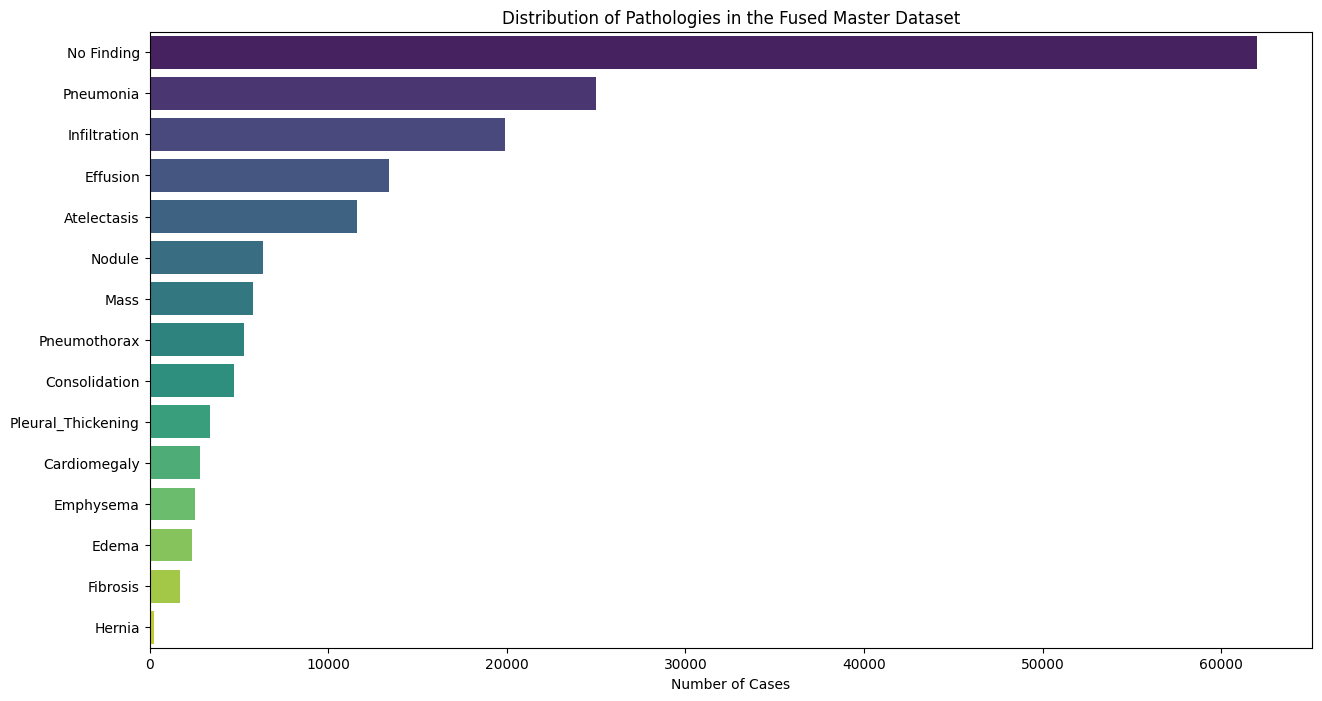

In [6]:
# --- Step 4: Fuse all datasets into a master DataFrame ---
print("Fusing all datasets...")

# Select only the relevant columns from each dataframe before concatenating
nih_subset = nih_df[['filepath'] + MASTER_FINDINGS]
chexpert_subset = chexpert_df[['filepath'] + MASTER_FINDINGS]
pneumonia_subset = pneumonia_df[['filepath'] + MASTER_FINDINGS + ['Subtype', 'Severity_Simulated']]

# Combine the dataframes
master_df = pd.concat([nih_subset, chexpert_subset, pneumonia_subset], ignore_index=True)
master_df = master_df.fillna('N/A') # Fill NaN in subtype/severity for NIH/CheXpert data

# Remove duplicates if any
master_df = master_df.drop_duplicates(subset=['filepath'])

# Clean up memory
del nih_df, chexpert_df, pneumonia_df, nih_subset, chexpert_subset
gc.collect()

print(f"Data fusion complete. Total unique images in master dataset: {master_df.shape[0]}")

# Let's see the distribution of findings in our final dataset
findings_counts = master_df[MASTER_FINDINGS].sum().sort_values(ascending=False)
plt.figure(figsize=(15, 8))
sns.barplot(x=findings_counts.values, y=findings_counts.index, palette='viridis')
plt.title('Distribution of Pathologies in the Fused Master Dataset')
plt.xlabel('Number of Cases')
plt.show()

In [7]:
# --- Step 5: Split data and create Keras ImageDataGenerators ---
# We will use a smaller fraction of the data for this demo to train quickly on Kaggle.
# For a full model, use frac=1.0
sample_df = master_df.sample(frac=0.2, random_state=42)

# Split into training and validation sets
train_df, valid_df = train_test_split(sample_df, test_size=0.15, random_state=42)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(valid_df)}")


# Create data generators with augmentation for the training set
IMG_SIZE = (256, 256) # Using a slightly larger image size for better feature extraction
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255.,
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1
)

# No augmentation for the validation set, only rescaling
valid_datagen = ImageDataGenerator(rescale=1./255.)

# Create generators using flow_from_dataframe for multi-label classification
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col=MASTER_FINDINGS,
    target_size=IMG_SIZE,
    class_mode='raw', # CRITICAL for multi-label
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='filepath',
    y_col=MASTER_FINDINGS,
    target_size=IMG_SIZE,
    class_mode='raw', # CRITICAL for multi-label
    batch_size=BATCH_SIZE,
    shuffle=False
)

Training set size: 20095
Validation set size: 3547
Found 1015 validated image filenames.
Found 171 validated image filenames.
